In [1]:
import pandas as pd

df = pd.read_csv('filtered-data/muestra_ratings.csv')

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

from surprise import Dataset, Reader, KNNBasic

config = {
    'test_size': 0.2,
    'random_state': 42,
    'k_neighbors': 40,
    'min_k': 1,
    'user_caps': [8000, 6000, 4000, 2500],
    'max_test_eval': 20000,
}

train_df, test_df = train_test_split(
    df[['userId', 'movieId', 'rating']].copy(),
    test_size=config['test_size'],
    random_state=config['random_state']
 )

def _metrics_from_preds(y_true_arr, y_pred_arr, n_test):
    rmse_val = float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2))) if len(y_true_arr) else float('nan')
    mae_val = float(np.mean(np.abs(y_true_arr - y_pred_arr))) if len(y_true_arr) else float('nan')
    coverage_val = float(len(y_pred_arr) / n_test) if n_test else 0.0
    return rmse_val, mae_val, coverage_val

def _build_attempt_data(train_base_df, test_base_df, max_users, max_test_eval, random_state):
    user_counts = train_base_df['userId'].value_counts()
    if max_users is not None and len(user_counts) > max_users:
        keep_users = set(user_counts.head(max_users).index)
    else:
        keep_users = set(user_counts.index)

    train_attempt_df = train_base_df[train_base_df['userId'].isin(keep_users)].copy()

    train_users = set(train_attempt_df['userId'].unique())
    train_items = set(train_attempt_df['movieId'].unique())
    test_attempt_df = test_base_df[
        test_base_df['userId'].isin(train_users) &
        test_base_df['movieId'].isin(train_items)
    ].copy()

    if max_test_eval is not None and len(test_attempt_df) > max_test_eval:
        test_attempt_df = test_attempt_df.sample(n=max_test_eval, random_state=random_state)

    return train_attempt_df, test_attempt_df

trained_models = {}
model_results = []
attempt_logs = []

reader = Reader(rating_scale=(0.5, 5.0))

surprise_specs = [
    ('user_user_cosine', {'name': 'cosine', 'user_based': True}),
    ('user_user_pearson', {'name': 'pearson', 'user_based': True}),
    ('item_item_cosine', {'name': 'cosine', 'user_based': False}),
    ('item_item_pearson', {'name': 'pearson', 'user_based': False}),
]

for model_name, sim_options in surprise_specs:
    model_succeeded = False
    last_error = None

    for attempt_idx, user_cap in enumerate(config['user_caps'], start=1):
        train_attempt_df, test_attempt_df = _build_attempt_data(
            train_df,
            test_df,
            user_cap,
            config['max_test_eval'],
            config['random_state']
        )

        if len(train_attempt_df) == 0 or len(test_attempt_df) == 0:
            last_error = 'Empty train/test after filtering for this tier'
            attempt_logs.append({
                'model_name': model_name,
                'attempt': attempt_idx,
                'user_cap': user_cap,
                'status': 'failed',
                'train_ratings': int(len(train_attempt_df)),
                'test_ratings': int(len(test_attempt_df)),
                'error': last_error
            })
            continue

        y_true_attempt = np.array(test_attempt_df['rating'].astype(float).values, dtype=np.float32)

        try:
            train_data = Dataset.load_from_df(train_attempt_df[['userId', 'movieId', 'rating']], reader)
            trainset = train_data.build_full_trainset()

            algo_i = KNNBasic(
                k=config['k_neighbors'],
                min_k=config['min_k'],
                sim_options=sim_options,
                verbose=False
            )
            algo_i.fit(trainset)

            y_pred_i = np.array([
                float(algo_i.predict(uid=row.userId, iid=row.movieId, r_ui=row.rating).est)
                for row in test_attempt_df[['userId', 'movieId', 'rating']].itertuples(index=False)
            ], dtype=np.float32)

            rmse_i, mae_i, coverage_i = _metrics_from_preds(y_true_attempt, y_pred_i, len(test_attempt_df))

            trained_models[model_name] = algo_i
            attempt_logs.append({
                'model_name': model_name,
                'attempt': attempt_idx,
                'user_cap': user_cap,
                'status': 'success',
                'train_ratings': int(len(train_attempt_df)),
                'test_ratings': int(len(test_attempt_df)),
                'error': ''
            })

            model_results.append({
                'model_name': model_name,
                'status': 'success',
                'attempts_used': attempt_idx,
                'selected_user_cap': int(user_cap),
                'user_based': bool(sim_options['user_based']),
                'similarity': sim_options['name'],
                'train_users': int(train_attempt_df['userId'].nunique()),
                'train_items': int(train_attempt_df['movieId'].nunique()),
                'train_ratings': int(len(train_attempt_df)),
                'test_ratings': int(len(test_attempt_df)),
                'rmse': rmse_i,
                'mae': mae_i,
                'coverage': coverage_i,
                'last_error': ''
            })
            model_succeeded = True
            break

        except Exception as err:
            last_error = f"{type(err).__name__}: {err}"
            attempt_logs.append({
                'model_name': model_name,
                'attempt': attempt_idx,
                'user_cap': user_cap,
                'status': 'failed',
                'train_ratings': int(len(train_attempt_df)),
                'test_ratings': int(len(test_attempt_df)),
                'error': last_error
            })

    if not model_succeeded:
        model_results.append({
            'model_name': model_name,
            'status': 'failed',
            'attempts_used': len(config['user_caps']),
            'selected_user_cap': np.nan,
            'user_based': bool(sim_options['user_based']),
            'similarity': sim_options['name'],
            'train_users': np.nan,
            'train_items': np.nan,
            'train_ratings': np.nan,
            'test_ratings': np.nan,
            'rmse': np.nan,
            'mae': np.nan,
            'coverage': np.nan,
            'last_error': last_error if last_error is not None else 'Unknown error'
        })

metrics_df = pd.DataFrame(model_results).sort_values(['status', 'user_based', 'similarity', 'model_name']).reset_index(drop=True)
attempts_df = pd.DataFrame(attempt_logs).sort_values(['model_name', 'attempt']).reset_index(drop=True)

print(f"Modelos exitosos: {(metrics_df['status'] == 'success').sum()} / {len(metrics_df)}")
metrics_df

Modelos exitosos: 4 / 4


,model_name,status,attempts_used,selected_user_cap,user_based,similarity,train_users,train_items,train_ratings,test_ratings,rmse,mae,coverage,last_error
0,item_item_cosine,success,1,8000,False,cosine,8000,16076,552371,20000,0.960592,0.746222,1.0,
1,item_item_pearson,success,1,8000,False,pearson,8000,16076,552371,20000,0.975135,0.754951,1.0,
2,user_user_cosine,success,1,8000,True,cosine,8000,16076,552371,20000,0.928501,0.721545,1.0,
3,user_user_pearson,success,1,8000,True,pearson,8000,16076,552371,20000,0.939033,0.729673,1.0,


## Metricas por modelo
Visualizar RMSE (principal), MAE y coverage para comparar el desempeno de recomendacion entre los modelos entrenados.

Modelos ordenados por RMSE (menor es mejor):


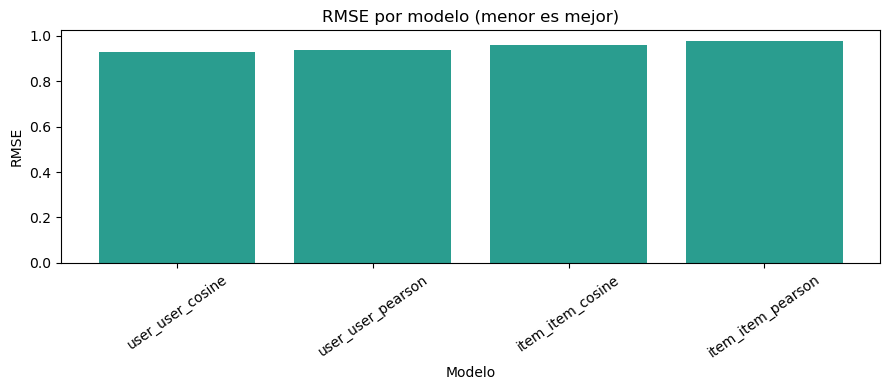

In [3]:
import matplotlib.pyplot as plt

metrics_view = (
    metrics_df.loc[metrics_df['status'] == 'success', [
        'model_name', 'similarity', 'user_based', 'selected_user_cap',
        'rmse', 'mae', 'coverage', 'train_ratings', 'test_ratings'
    ]]
    .sort_values('rmse')
    .reset_index(drop=True)
)

print('Modelos ordenados por RMSE (menor es mejor):')
metrics_view

if not metrics_view.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(metrics_view['model_name'], metrics_view['rmse'], color='#2a9d8f')
    ax.set_title('RMSE por modelo (menor es mejor)')
    ax.set_xlabel('Modelo')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()
else:
    print('No hay modelos exitosos para graficar RMSE.')

## Distribuciones con user caps
Se comparan las distribuciones del dataset original y del dataset filtrado por cada `user_cap`: rating general, media por usuario y cantidad de ratings por usuario.

Resumen de distribuciones por user_cap:


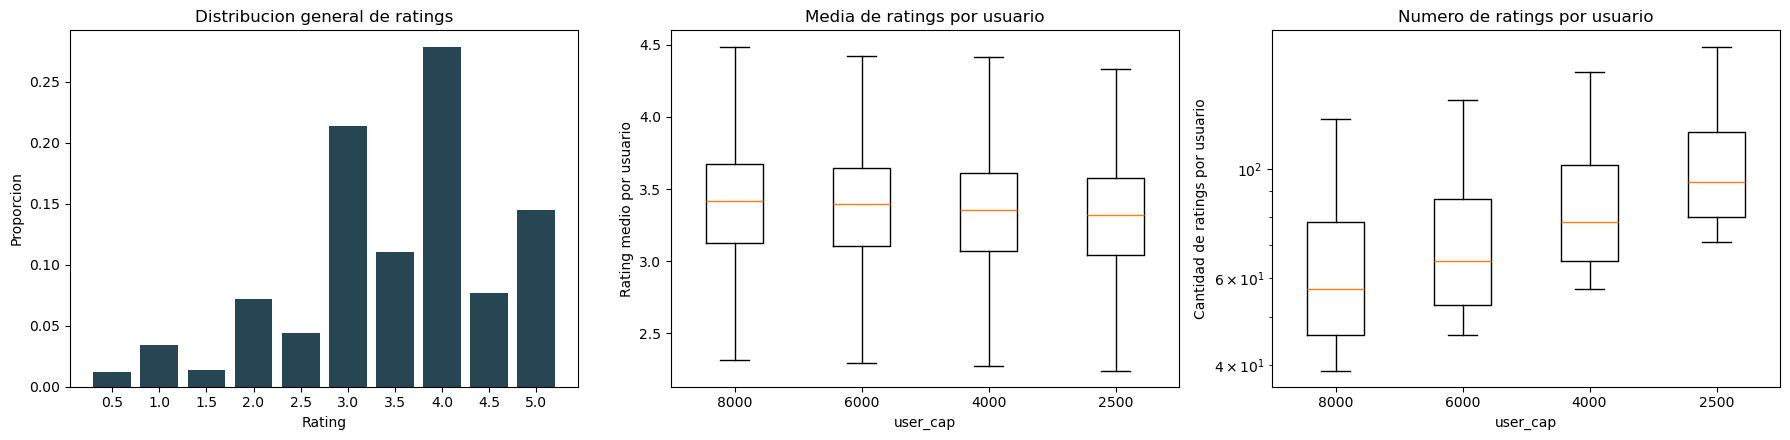

Distribucion de ratings por user_cap (proporcion):


user_cap,2500,4000,6000,8000
rating,,,,
0.5,0.017001,0.016223,0.015503,0.014899
1.0,0.038364,0.038069,0.037355,0.037162
1.5,0.024338,0.022726,0.021485,0.020638
2.0,0.092552,0.090148,0.087747,0.085872
2.5,0.078060,0.073527,0.070053,0.067074
3.0,0.223040,0.220563,0.217826,0.215263
3.5,0.151161,0.148868,0.146180,0.144182
4.0,0.235115,0.242802,0.249593,0.254130
4.5,0.065948,0.067525,0.069778,0.071847


In [4]:
cap_summary_rows = []
cap_rating_dist_rows = []
cap_user_profiles = []

for cap in config['user_caps']:
    train_attempt_df, _ = _build_attempt_data(
        train_df,
        test_df,
        cap,
        config['max_test_eval'],
        config['random_state']
    )

    if train_attempt_df.empty:
        continue

    user_profile = (
        train_attempt_df
        .groupby('userId')['rating']
        .agg(user_mean_rating='mean', num_ratings='size')
        .reset_index()
    )
    user_profile['user_cap'] = int(cap)
    cap_user_profiles.append(user_profile)

    rating_dist = (
        train_attempt_df['rating']
        .value_counts(normalize=True)
        .sort_index()
    )

    for rating_value, proportion in rating_dist.items():
        cap_rating_dist_rows.append({
            'user_cap': int(cap),
            'rating': float(rating_value),
            'proportion': float(proportion)
        })

    cap_summary_rows.append({
        'user_cap': int(cap),
        'users_kept': int(train_attempt_df['userId'].nunique()),
        'ratings_kept': int(len(train_attempt_df)),
        'mean_user_rating_mean': float(user_profile['user_mean_rating'].mean()),
        'median_user_rating_mean': float(user_profile['user_mean_rating'].median()),
        'mean_num_ratings_per_user': float(user_profile['num_ratings'].mean()),
        'median_num_ratings_per_user': float(user_profile['num_ratings'].median())
    })

cap_summary_df = pd.DataFrame(cap_summary_rows).sort_values('user_cap', ascending=False).reset_index(drop=True)
cap_rating_dist_df = pd.DataFrame(cap_rating_dist_rows).sort_values(['user_cap', 'rating']).reset_index(drop=True)
cap_user_profile_df = pd.concat(cap_user_profiles, ignore_index=True) if cap_user_profiles else pd.DataFrame()

print('Resumen de distribuciones por user_cap:')
cap_summary_df

# 1) Distribucion general de ratings (dataset completo)
global_rating_dist = (
    df['rating']
    .value_counts(normalize=True)
    .sort_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].bar(global_rating_dist.index.astype(str), global_rating_dist.values, color='#264653')
axes[0].set_title('Distribucion general de ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Proporcion')

# 2) Distribucion de media de ratings por usuario para cada user_cap
if not cap_user_profile_df.empty:
    caps_sorted = sorted(cap_user_profile_df['user_cap'].unique(), reverse=True)
    mean_series_by_cap = [
        cap_user_profile_df.loc[cap_user_profile_df['user_cap'] == cap, 'user_mean_rating'].values
        for cap in caps_sorted
    ]
    axes[1].boxplot(mean_series_by_cap, labels=[str(c) for c in caps_sorted], showfliers=False)
    axes[1].set_title('Media de ratings por usuario')
    axes[1].set_xlabel('user_cap')
    axes[1].set_ylabel('Rating medio por usuario')

    # 3) Distribucion del numero de ratings por usuario para cada user_cap
    count_series_by_cap = [
        cap_user_profile_df.loc[cap_user_profile_df['user_cap'] == cap, 'num_ratings'].values
        for cap in caps_sorted
    ]
    axes[2].boxplot(count_series_by_cap, labels=[str(c) for c in caps_sorted], showfliers=False)
    axes[2].set_title('Numero de ratings por usuario')
    axes[2].set_xlabel('user_cap')
    axes[2].set_ylabel('Cantidad de ratings por usuario')
    axes[2].set_yscale('log')
else:
    axes[1].text(0.5, 0.5, 'Sin datos por user_cap', ha='center', va='center')
    axes[1].set_title('Media de ratings por usuario')
    axes[1].axis('off')

    axes[2].text(0.5, 0.5, 'Sin datos por user_cap', ha='center', va='center')
    axes[2].set_title('Numero de ratings por usuario')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

# Vista tabular de la distribucion de ratings por user_cap
cap_rating_pivot = cap_rating_dist_df.pivot(index='rating', columns='user_cap', values='proportion') if not cap_rating_dist_df.empty else pd.DataFrame()
print('Distribucion de ratings por user_cap (proporcion):')
cap_rating_pivot

### Cantidad de usuarios vs numero de ratings (por user_cap)
Para cada `user_cap`, se muestra cuantas personas tienen 1, 2, 3, ... ratings en el set de entrenamiento filtrado.

Tabla: cantidad de usuarios por numero de ratings y user_cap


user_cap,2500,4000,6000,8000
num_ratings,,,,
39,0,0,0,232
40,0,0,0,317
41,0,0,0,312
42,0,0,0,298
43,0,0,0,260
...,...,...,...,...
456,1,1,1,1
471,1,1,1,1
482,1,1,1,1


Tabla: cantidad de usuarios por numero de ratings y user_cap


user_cap,2500,4000,6000,8000
num_ratings,,,,
39,0,0,0,232
40,0,0,0,317
41,0,0,0,312
42,0,0,0,298
43,0,0,0,260
...,...,...,...,...
456,1,1,1,1
471,1,1,1,1
482,1,1,1,1


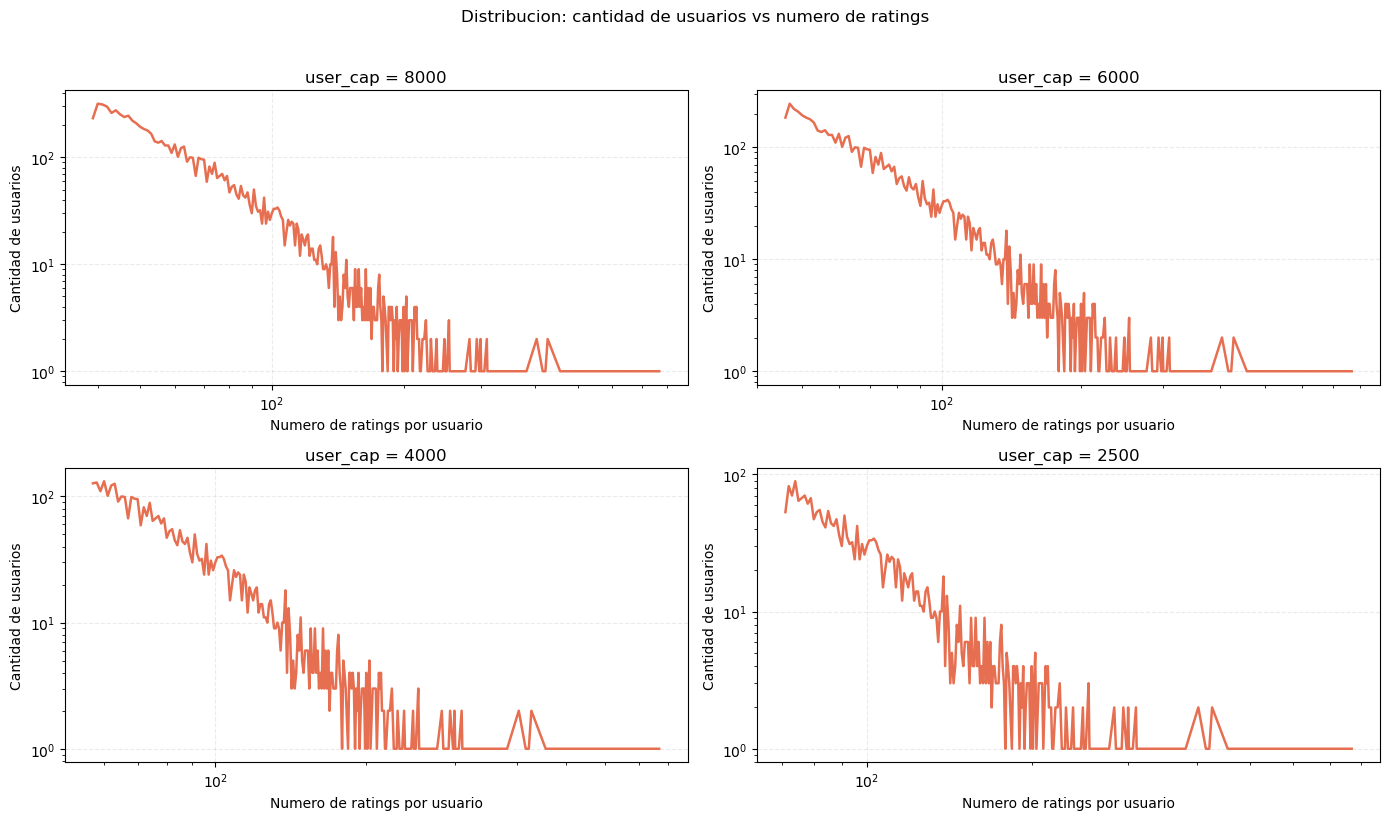

In [6]:
if cap_user_profile_df.empty:
    print('No hay datos para construir la distribucion por user_cap.')
else:
    users_vs_ratings_df = (
        cap_user_profile_df
        .groupby(['user_cap', 'num_ratings'])
        .size()
        .reset_index(name='num_users')
        .sort_values(['user_cap', 'num_ratings'], ascending=[False, True])
        .reset_index(drop=True)
    )

    users_vs_ratings_pivot = users_vs_ratings_df.pivot(
        index='num_ratings',
        columns='user_cap',
        values='num_users'
    ).fillna(0).astype(int)

    print('Tabla: cantidad de usuarios por numero de ratings y user_cap')
    display(users_vs_ratings_pivot)

    caps_sorted = sorted(users_vs_ratings_df['user_cap'].unique(), reverse=True)
    n_caps = len(caps_sorted)
    n_cols = 2
    n_rows = int(np.ceil(n_caps / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for idx, cap in enumerate(caps_sorted):
        ax = axes[idx]
        data_cap = users_vs_ratings_df[users_vs_ratings_df['user_cap'] == cap]

        ax.plot(data_cap['num_ratings'], data_cap['num_users'], color='#e76f51', linewidth=1.8)
        ax.set_title(f'user_cap = {cap}')
        ax.set_xlabel('Numero de ratings por usuario')
        ax.set_ylabel('Cantidad de usuarios')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(alpha=0.25, linestyle='--')

    for j in range(n_caps, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Distribucion: cantidad de usuarios vs numero de ratings', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

## Exportar modelos
Guardar los 4 modelos entrenados (cosine/pearson, user-user/item-item) y su metadata.

In [5]:
from pathlib import Path
from surprise import dump
import json

model_dir = Path('artifacts')
model_dir.mkdir(parents=True, exist_ok=True)

export_rows = []

for model_name, model_obj in trained_models.items():
    row = metrics_df.loc[metrics_df['model_name'] == model_name].iloc[0]

    model_path = model_dir / f'model_{model_name}.pkl'
    metadata_path = model_dir / f'model_{model_name}_metadata.json'

    dump.dump(str(model_path), algo=model_obj)

    metadata = {
        'model_name': model_name,
        'backend': 'surprise',
        'algorithm': 'KNNBasic',
        'library': 'surprise',
        'status': str(row['status']),
        'similarity': str(row['similarity']),
        'user_based': bool(row['user_based']),
        'k_neighbors': int(config['k_neighbors']),
        'min_k': int(config['min_k']),
        'attempts_used': int(row['attempts_used']),
        'selected_user_cap': int(row['selected_user_cap']),
        'fallback_tiers': [int(v) for v in config['user_caps']],
        'max_test_eval': int(config['max_test_eval']),
        'train_users': int(row['train_users']),
        'train_items': int(row['train_items']),
        'train_ratings': int(row['train_ratings']),
        'test_ratings': int(row['test_ratings']),
        'rmse': float(row['rmse']),
        'mae': float(row['mae']),
        'coverage': float(row['coverage'])
    }

    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    export_rows.append({
        'model_name': model_name,
        'status': str(row['status']),
        'attempts_used': int(row['attempts_used']),
        'selected_user_cap': int(row['selected_user_cap']),
        'backend': 'surprise',
        'model_path': str(model_path),
        'metadata_path': str(metadata_path)
    })

failed_models_df = metrics_df.loc[metrics_df['status'] != 'success', ['model_name', 'last_error']].copy()

if failed_models_df.empty:
    print('Todos los modelos se entrenaron y exportaron correctamente.')
else:
    print('Modelos que no se pudieron entrenar despues de todos los intentos:')
    print(failed_models_df.to_string(index=False))

export_df = pd.DataFrame(export_rows).sort_values('model_name').reset_index(drop=True) if export_rows else pd.DataFrame(
    columns=['model_name', 'status', 'attempts_used', 'selected_user_cap', 'backend', 'model_path', 'metadata_path']
)
export_df

Todos los modelos se entrenaron y exportaron correctamente.


,model_name,status,attempts_used,selected_user_cap,backend,model_path,metadata_path
0,item_item_cosine,success,1,8000,surprise,artifacts/model_item_item_cosine.pkl,artifacts/model_item_item_cosine_metadata.json
1,item_item_pearson,success,1,8000,surprise,artifacts/model_item_item_pearson.pkl,artifacts/model_item_item_pearson_metadata.json
2,user_user_cosine,success,1,8000,surprise,artifacts/model_user_user_cosine.pkl,artifacts/model_user_user_cosine_metadata.json
3,user_user_pearson,success,1,8000,surprise,artifacts/model_user_user_pearson.pkl,artifacts/model_user_user_pearson_metadata.json
